## EDA: Signals and Data Quality

Signal-level EDA on the cleaned data from `01_data_cleaning.ipynb` (run that notebook first). This covers example ECGs, signal quality and label validation, recording devices, signal amplitude, the average heartbeat by sex, and the hypertrophy voltage criterion.

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

PATH = "../data/"
os.makedirs("../figures", exist_ok=True)

def save(name):
    plt.savefig(f"../figures/{name}.png", dpi=150, bbox_inches="tight")

In [60]:
df = pd.read_pickle(PATH + "ptbxl_clean.pkl")
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

In [61]:
print(df.shape)
df.head()

(20370, 35)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,filename_lr,filename_hr,sex_label,age_band,labels,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,records100/00000/00001_lr,records500/00000/00001_hr,female,40-60,[NORM],1,0,0,0,0
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,records100/00000/00003_lr,records500/00000/00003_hr,female,<40,[NORM],1,0,0,0,0
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,records100/00000/00004_lr,records500/00000/00004_hr,male,<40,[NORM],1,0,0,0,0
7,16193.0,54.0,0,NaN,83.0,2.0,0.0,CS-12 E,1984-11-28 13:32:22,"sinusrhythmus linkstyp t abnormal, wahrscheinl...",...,records100/00000/00007_lr,records500/00000/00007_hr,male,40-60,[NORM],1,0,0,0,0
8,11275.0,48.0,0,NaN,95.0,2.0,0.0,CS-12 E,1984-12-01 14:49:52,sinusrhythmus linkstyp qrs(t) abnormal infe...,...,records100/00000/00008_lr,records500/00000/00008_hr,male,40-60,[MI],0,1,0,0,0


### Example ECGs by Diagnosis

One single-diagnosis example per superclass, male vs. female. Lead II (standard rhythm lead) and V1 (where sex differences are strongest) are shown.

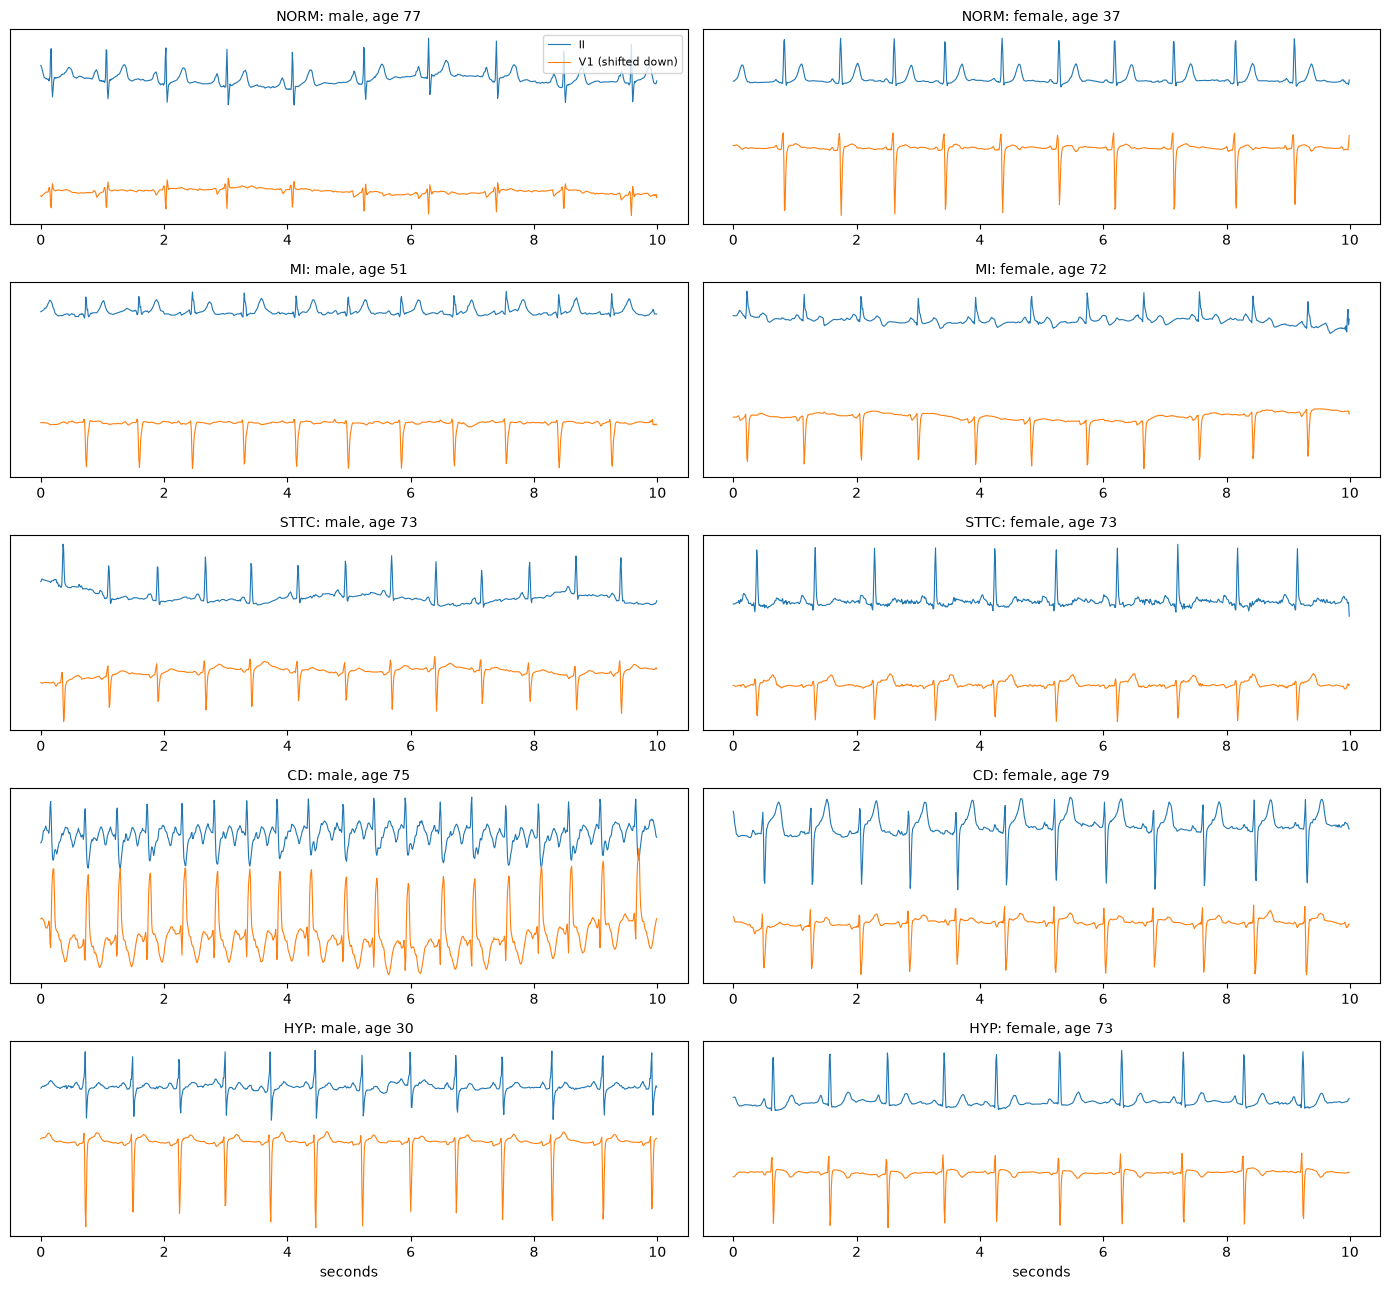

In [62]:
single = df[df["labels"].apply(len) == 1]
t = np.arange(1000) / 100

plt.figure(figsize=(14, 13))
for i, c in enumerate(CLASSES):
    for j, s in enumerate(["male", "female"]):
        rec = single[(single[c] == 1) & (single["sex_label"] == s)].sample(1, random_state=0)
        sig, _ = wfdb.rdsamp(PATH + rec["filename_lr"].iloc[0])
        plt.subplot(5, 2, i * 2 + j + 1)
        plt.plot(t, sig[:, 1], lw=0.8, label="II")
        plt.plot(t, sig[:, 6] - 1.5, lw=0.8, label="V1 (shifted down)")
        plt.title(f"{c}: {s}, age {int(rec['age'].iloc[0])}", fontsize=10)
        plt.yticks([])
        if i == 0 and j == 0:
            plt.legend(loc="upper right", fontsize=8)
        if i == 4:
            plt.xlabel("seconds")
plt.tight_layout()
save("ecg_examples_by_diagnosis")
plt.show()

**Takeaway:** Diagnoses look visibly different: the CD example shows wide, notched QRS complexes (a slowed electrical path), while NORM shows narrow, regular beats. Examples are single records and not representative of every patient.

### Signal Quality Flags by Sex

PTB-XL notes recording problems per ECG: baseline drift (slow wandering), static noise (constant fuzz), burst noise (sudden spikes), electrode problems, extra beats, and pacemaker spikes.

In [63]:
FLAGS = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems", "extra_beats", "pacemaker"]
flag_pct = df[FLAGS].notna().groupby(df["sex_label"]).mean() * 100
print(flag_pct.round(1).T)

sex_label            female  male
baseline_drift          7.9   6.3
static_noise           14.2  15.8
burst_noise             2.2   3.4
electrodes_problems     0.2   0.1
extra_beats             7.5   9.8
pacemaker               1.3   1.4


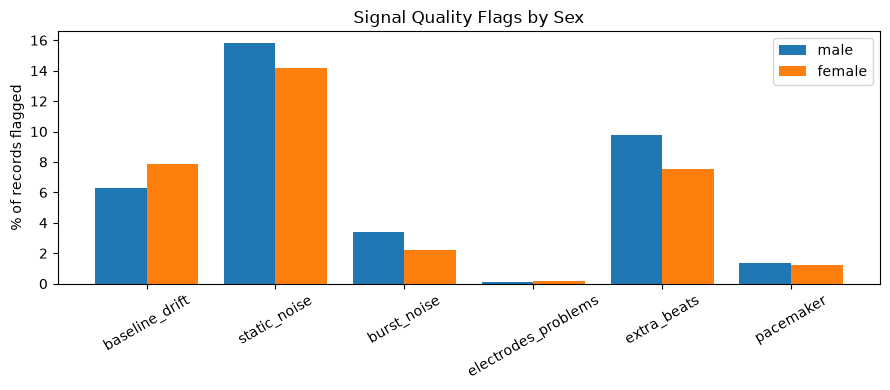

In [64]:
x = np.arange(len(FLAGS))
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, flag_pct.loc["male"], width=0.4, label="male")
plt.bar(x + 0.2, flag_pct.loc["female"], width=0.4, label="female")
plt.xticks(x, FLAGS, rotation=30)
plt.title("Signal Quality Flags by Sex")
plt.ylabel("% of records flagged")
plt.legend()
plt.tight_layout()
save("signal_quality_flags_by_sex")
plt.show()

**Takeaway:** Noise is common but similar by sex. Static noise affects ~15% of records for both. Women have slightly more baseline drift (7.9% vs 6.3%); men have slightly more burst noise (3.4% vs 2.2%) and extra beats (9.8% vs 7.5%). No flag differs enough by sex to drive a sex-based performance gap on its own.

### Label Validation by Fold

About a third of training labels (folds 1–8) come from auto-generated reports never checked by a cardiologist. Folds 9–10 are fully human-validated, which is why they are the test set.

strat_fold
1      65.5
2      64.7
3      64.7
4      66.4
5      66.1
6      62.4
7      66.1
8      66.0
9     100.0
10    100.0
Name: validated_by_human, dtype: float64


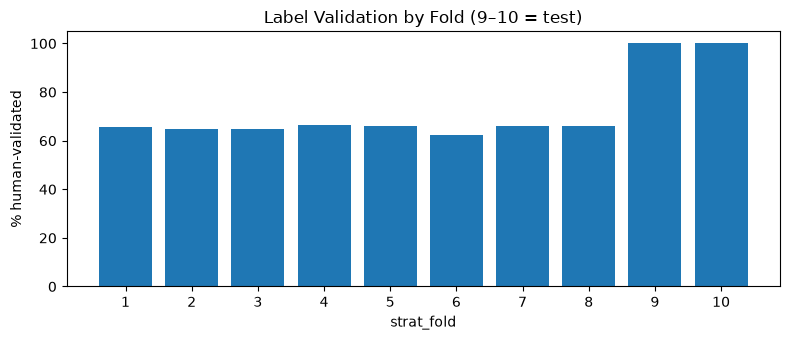

In [65]:
val = df.groupby("strat_fold")["validated_by_human"].mean() * 100
print(val.round(1))

plt.figure(figsize=(8, 3.5))
plt.bar(val.index, val.values)
plt.xticks(val.index)
plt.title("Label Validation by Fold (9–10 = test)")
plt.xlabel("strat_fold")
plt.ylabel("% human-validated")
plt.tight_layout()
save("label_validation_by_fold")
plt.show()

**Takeaway:** Folds 1–8 are only 62–66% human-validated, so roughly a third of training labels are unreviewed machine reports. Folds 9–10 are 100% validated, which confirms them as the test set.

### Recording Device by Sex

If men and women were recorded on different machines, a model could learn the device instead of sex. This is a confound to check before attributing any effect to sex.

In [66]:
dev = pd.crosstab(df["device"], df["sex_label"], normalize="columns") * 100
print(dev.round(1))

sex_label   female  male
device                  
AT-6     6    11.9   9.0
AT-6 C         2.3   2.5
AT-6 C 5.0     0.4   0.2
AT-6 C 5.3     0.4   0.3
AT-6 C 5.5    20.2  16.0
AT-6 C 5.6     0.3   0.2
AT-6 C 5.8     4.3   3.3
AT-60    3     5.1   3.7
CS-12         21.0  15.8
CS-12   E     12.9  11.8
CS100    3    21.2  37.2


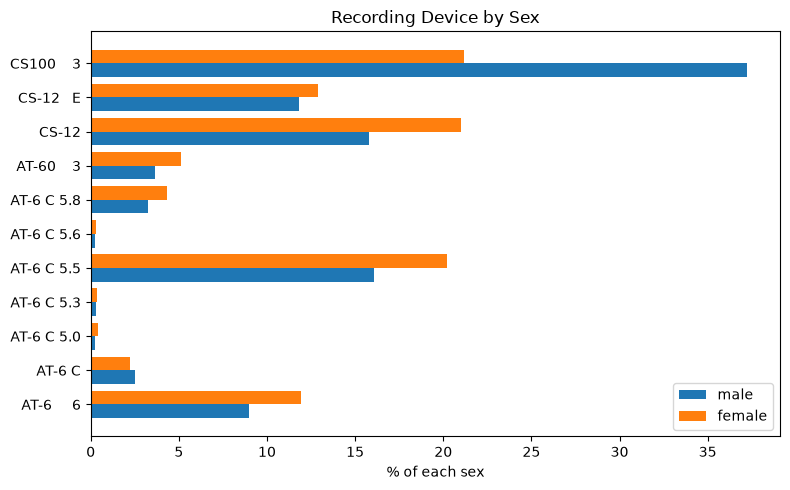

In [67]:
y = np.arange(len(dev))
plt.figure(figsize=(8, 5))
plt.barh(y - 0.2, dev["male"], height=0.4, label="male")
plt.barh(y + 0.2, dev["female"], height=0.4, label="female")
plt.yticks(y, dev.index)
plt.title("Recording Device by Sex")
plt.xlabel("% of each sex")
plt.legend()
plt.tight_layout()
save("device_by_sex")
plt.show()

**Takeaway:** This is the largest imbalance in the metadata. The CS100 device recorded 37.2% of men but only 21.2% of women. A model could learn device-specific artifacts that correlate with sex, so any sex gap we find must be checked against device before attributing it to physiology.

### Signal Amplitude by Lead

Peak-to-peak amplitude (tallest point minus lowest point) per lead, on a random sample of 1,000 ECGs.

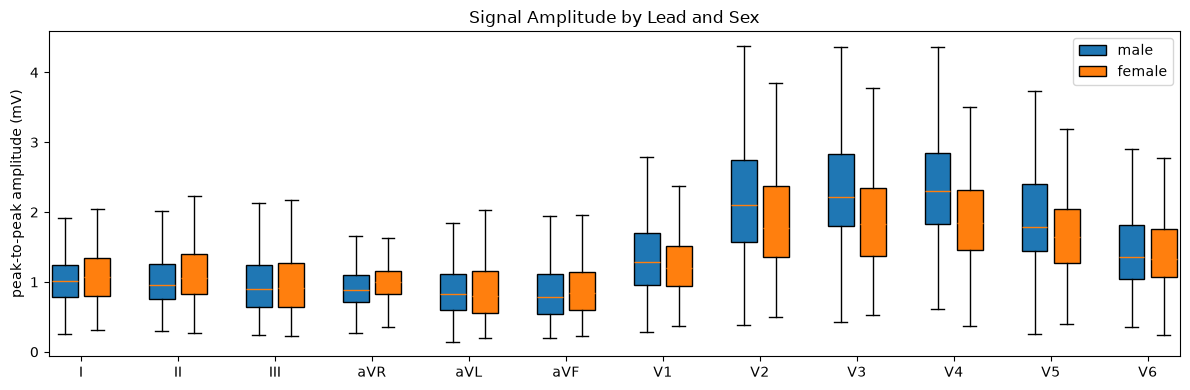

In [68]:
samp = df.sample(1000, random_state=0)
rows = []
for eid, row in samp.iterrows():
    sig, _ = wfdb.rdsamp(PATH + row["filename_lr"])
    amp = sig.max(axis=0) - sig.min(axis=0)
    rows.append(dict(zip(LEAD_NAMES, amp), sex=row["sex_label"]))
amp_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 4))
male_box = plt.boxplot([amp_df[amp_df["sex"] == "male"][l] for l in LEAD_NAMES],
                       positions=np.arange(12) * 3, widths=0.8, showfliers=False, patch_artist=True)
female_box = plt.boxplot([amp_df[amp_df["sex"] == "female"][l] for l in LEAD_NAMES],
                         positions=np.arange(12) * 3 + 1, widths=0.8, showfliers=False, patch_artist=True)
for b in male_box["boxes"]:
    b.set_facecolor("C0")
for b in female_box["boxes"]:
    b.set_facecolor("C1")
plt.xticks(np.arange(12) * 3 + 0.5, LEAD_NAMES)
plt.legend([male_box["boxes"][0], female_box["boxes"][0]], ["male", "female"])
plt.title("Signal Amplitude by Lead and Sex")
plt.ylabel("peak-to-peak amplitude (mV)")
plt.tight_layout()
save("signal_amplitude_by_lead")
plt.show()

**Takeaway:** Women have lower voltages in the chest leads (V2–V5), while limb leads are similar. This matches the clinical literature and means a single voltage threshold will not behave the same for both sexes.

### Average Heartbeat by Sex

For normal ECGs only (no pacemaker), every beat is lined up on its R peak (the tallest spike) and averaged, giving one typical heartbeat per patient, then averaged across patients by sex.

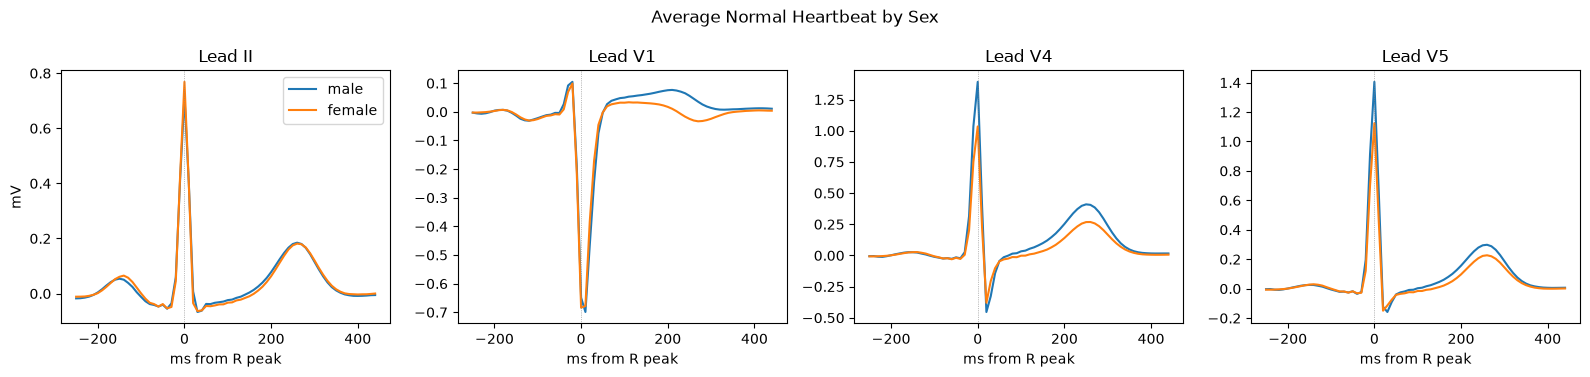

In [69]:
from scipy.signal import find_peaks

def avg_beat(sig, pre=25, post=45):
    ii = sig[:, 1] - np.median(sig[:, 1])
    peaks, _ = find_peaks(ii, distance=30, height=0.5 * ii.max())
    peaks = peaks[(peaks > pre) & (peaks < len(ii) - post)]
    if len(peaks) < 3:
        return None, None
    beat = np.median(np.stack([sig[p - pre:p + post] for p in peaks]), axis=0)
    beat = beat - np.median(beat[:10], axis=0)
    hr = 60 / (np.median(np.diff(peaks)) / 100)
    return beat, hr

norm = df[(df["NORM"] == 1) & (df["labels"].apply(len) == 1) & df["pacemaker"].isna()]
beats = {"male": [], "female": []}
hrs = {"male": [], "female": []}
for eid, row in norm.sample(min(1000, len(norm)), random_state=0).iterrows():
    sig, _ = wfdb.rdsamp(PATH + row["filename_lr"])
    b, hr = avg_beat(sig)
    if b is not None:
        beats[row["sex_label"]].append(b)
        hrs[row["sex_label"]].append(hr)

tb = (np.arange(70) - 25) * 10
plt.figure(figsize=(16, 3.8))
for i, (name, k) in enumerate([("II", 1), ("V1", 6), ("V4", 9), ("V5", 10)]):
    plt.subplot(1, 4, i + 1)
    for s in ["male", "female"]:
        plt.plot(tb, np.mean(beats[s], axis=0)[:, k], label=s)
    plt.axvline(0, color="grey", lw=0.5, ls=":")
    plt.title(f"Lead {name}")
    plt.xlabel("ms from R peak")
    if i == 0:
        plt.ylabel("mV")
        plt.legend()
plt.suptitle("Average Normal Heartbeat by Sex")
plt.tight_layout()
save("average_beat_by_sex")
plt.show()

**Takeaway:** In normal ECGs, lead II is nearly identical by sex, but in V4 and V5 the female R peak is clearly shorter (~1.05 vs ~1.4 mV) and the T wave is lower. V1 shows a flatter ST segment and T wave in women. Sex differences are concentrated in the chest leads and the ST/T region, which overlaps the features used to diagnose MI and STTC.

### Heart Rate by Sex

{'male': np.float64(65.9), 'female': np.float64(70.6)}


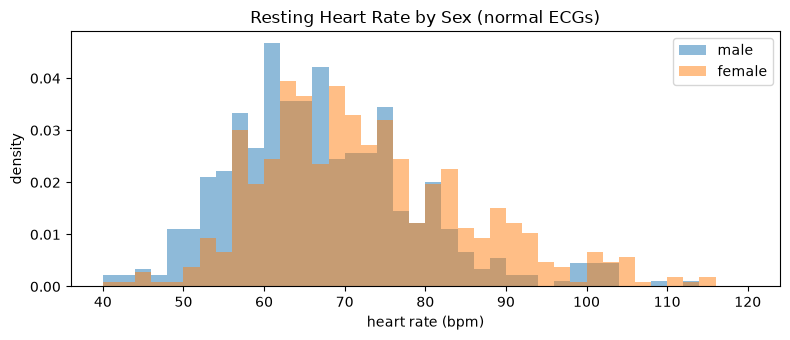

In [70]:
print({s: round(np.median(hrs[s]), 1) for s in hrs})

plt.figure(figsize=(8, 3.5))
plt.hist(hrs["male"], bins=40, range=(40, 120), alpha=0.5, density=True, label="male")
plt.hist(hrs["female"], bins=40, range=(40, 120), alpha=0.5, density=True, label="female")
plt.title("Resting Heart Rate by Sex (normal ECGs)")
plt.xlabel("heart rate (bpm)")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
save("heart_rate_by_sex")
plt.show()

**Takeaway:** Median resting heart rate is 70.6 bpm for women vs 65.9 for men, consistent with known physiology. Faster rates shorten the beat, which the model sees as a timing difference unrelated to disease.

### Hypertrophy Voltage Criterion by Sex

Sokolow-Lyon = S-wave depth in V1 + R-wave height in V5 or V6. Above 3.5 mV suggests left ventricular hypertrophy. Compared for patients labeled HYP vs. normal. This is a rough measurement (whole 10 s, not a single measured beat).

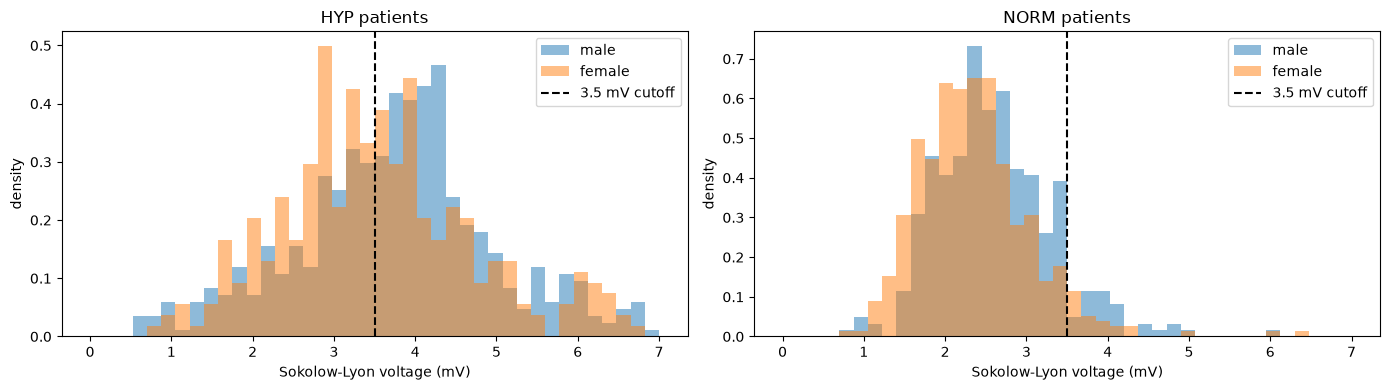

group  sex   
HYP    female    49.0
       male      61.5
NORM   female     5.3
       male       8.3
Name: sokolow, dtype: float64 % over cutoff


In [71]:
def sokolow(sig):
    base = np.median(sig, axis=0)
    s_v1 = base[6] - sig[:, 6].min()
    r_v5v6 = max(sig[:, 10].max() - base[10], sig[:, 11].max() - base[11])
    return s_v1 + r_v5v6

groups = {"HYP": df[df["HYP"] == 1],
          "NORM": df[(df["NORM"] == 1) & (df["labels"].apply(len) == 1)]}
rows = []
for grp, sub in groups.items():
    for eid, row in sub.sample(min(800, len(sub)), random_state=0).iterrows():
        sig, _ = wfdb.rdsamp(PATH + row["filename_lr"])
        rows.append({"group": grp, "sex": row["sex_label"], "sokolow": sokolow(sig)})
sl = pd.DataFrame(rows)

plt.figure(figsize=(14, 4))
for i, grp in enumerate(["HYP", "NORM"]):
    plt.subplot(1, 2, i + 1)
    for s in ["male", "female"]:
        plt.hist(sl[(sl["group"] == grp) & (sl["sex"] == s)]["sokolow"],
                 bins=40, range=(0, 7), alpha=0.5, density=True, label=s)
    plt.axvline(3.5, color="k", ls="--", label="3.5 mV cutoff")
    plt.title(f"{grp} patients")
    plt.xlabel("Sokolow-Lyon voltage (mV)")
    plt.ylabel("density")
    plt.legend()
plt.tight_layout()
save("sokolow_hyp_vs_norm")
plt.show()

print((sl.groupby(["group", "sex"])["sokolow"].apply(lambda x: (x > 3.5).mean()) * 100).round(1), "% over cutoff")

**Takeaway:** Among patients diagnosed with hypertrophy, only 49.0% of women exceed the 3.5 mV cutoff vs 61.5% of men. The standard voltage rule under-detects hypertrophy in women. Because labels in PTB-XL come from ECG-based reads, women with hypertrophy that the criteria miss may be labeled as not having it, and our evaluation cannot detect errors the labels share. This is a core limitation and motivation for the project.